*  DSC530 Data Exploration and Analysis
*  Weeks 7 & 8 Coding Assignment
*  Peter Lozano

In [136]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import seaborn as sns

fb = pd.read_csv('../../ch_05/data/fb_stock_prices_2018.csv', index_col='date', parse_dates=True)
quakes = pd.read_csv('../../ch_05/data/earthquakes.csv')
covid = pd.read_csv('../../ch_05/data/covid19_cases.csv').assign(
    date=lambda x: pd.to_datetime(x.dateRep, format='%d/%m/%Y')
).set_index('date').replace(
    'United_States_of_America', 'USA'
).sort_index()['2020-01-18':'2020-09-18']

Let's inspect the Facebook data

In [125]:
fb.head()

,open,high,low,close,volume
date,,,,,
2018-01-02,177.68,181.58,177.5500,181.42,18151903
2018-01-03,181.88,184.78,181.3300,184.67,16886563
2018-01-04,184.90,186.21,184.0996,184.33,13880896
2018-01-05,185.59,186.90,184.9300,186.85,13574535
2018-01-08,187.20,188.90,186.3300,188.28,17994726


## Exercise 1
> Plot the rolling 20-day minimum of the Facebook closing price using `pandas`.

In [126]:
# Calculate different rolling statistics for Facebook stock prices
rolling_min = fb.close.rolling('20D').min()
rolling_max = fb.close.rolling('20D').max()
rolling_mean = fb.close.rolling('20D').mean()

# Create figure with both traces
fig = go.Figure()

# Add min trace (visible by default)
fig.add_trace(go.Scatter(
    x=rolling_min.index,
    y=rolling_min.values,
    name='Minimum',
    visible=True,
    hovertemplate='<b>Rolling 20D Minimum</b><br>' +
                  'Date: %{x}<br>' +
                  'Price: $%{y:.2f}<extra></extra>'
))

# Add mean trace (hidden by default)
fig.add_trace(go.Scatter(
    x=rolling_mean.index,
    y=rolling_mean.values,
    name='Average',
    visible=False,
    hovertemplate='<b>Rolling 20D Average</b><br>' +
                  'Date: %{x}<br>' +
                  'Price: $%{y:.2f}<extra></extra>'
))
# Add max trace (hidden by default)
fig.add_trace(go.Scatter(
    x=rolling_max.index,
    y=rolling_max.values,
    name='Maximum',
    visible=False,
    hovertemplate='<b>Rolling 20D Maximum</b><br>' +
                  'Date: %{x}<br>' +
                  'Price: $%{y:.2f}<extra></extra>'
))

# Add dropdown menu
fig.update_layout(
    title='Rolling 20D Facebook Stock Price Analysis',
    xaxis_title='Date',
    yaxis_title='Price ($)',
    updatemenus=[
        dict(
            type="buttons",
            direction="down",
            showactive=True,
            x=.9,
            xanchor="left",
            y=1.02,
            yanchor="top",
            buttons=list([
                dict(
                    label="Minimum",
                    method="update",
                    args=[{"visible": [True, False, False]},
                          {"title": "Rolling 20D Minimum Closing Price of Facebook Stock"}]
                ),
                dict(
                    label="Maximum", 
                    method="update",
                    args=[{"visible": [False, True, False]},
                          {"title": "Rolling 20D Maximum Closing Price of Facebook Stock"}]
                ),
                dict(
                    label="Average", 
                    method="update",
                    args=[{"visible": [False, False, True]},
                          {"title": "Rolling 20D Average Closing Price of Facebook Stock"}]
                )
            ])
        )
    ]
)

fig.show()


The line graph defaults to the minimum but added functionality so that you can select between using **min**, **max**, or the **mean**.

## Exercise 2
> Create a histogram and KDE of the change from open to close in the price of Facebook stock.

First we need to calculate the change from open to close in the price of Facebook stock. Then we can create a histogram and KDE plot using `pandas` and `plotly`.

In [127]:
# Calculate the differential
differential = fb.open - fb.close

# Create Plotly figure with make_subplots for dual y-axes
# secondary_y=True allows us to have two y-axes
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Setting up the histogram and passing in to the dual y-axis figure
fig.add_trace(
    go.Histogram(
        # Setting x axis with the differential values
        x=differential,
        histnorm='probability density',
        opacity=.7,
        name='Histogram',
        # Setting to 30 to see how the distribution looks
        nbinsx=30
    ),
    # Setting the histogram to the primary y-axis
    secondary_y=False,
)
# Calculate and add KDE using scipy
kde = stats.gaussian_kde(differential)

# Dynamically create x values for KDE line
x_range = np.linspace(differential.min(), differential.max(), 100)
kde_values = kde(x_range)

# Add KDE line to the figure
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=kde_values,
        mode='lines',
        name='KDE',
        line=dict(color='blue', width=2)
    ),
    secondary_y=True,
)

# Update layout
fig.update_layout(
    title='Facebook Stock Price Daily Change from Open to Close',
    xaxis_title='Price Change ($)',
    showlegend=True
)

# Set y-axes titles
fig.update_yaxes(title_text="Probability Density", secondary_y=False)
fig.update_yaxes(title_text="KDE", secondary_y=True)

fig.show()

This looks like a normal distribution with a mean close to 0. The histogram shows that most of the daily changes are between -5 and +5 dollars.

## Exercise 3
> Using the earthquake data, create box plots for the magnitudes of each `magType` used in `Indonesia`.

In [128]:
# Filter earthquake data for Indonesia
indonesia_data = quakes.loc[quakes['parsed_place'] == 'Indonesia', ['mag', 'magType']]
indonesia_data.describe(include='object').T

,count,unique,top,freq
magType,147,4,mb,127


There are 4 different 'magType' values. We should anticipate 4 unique box plots.

In [129]:
# Create Plotly box plot
fig = px.box(
    indonesia_data, 
    x='magType', 
    y='mag',
    title='Earthquake Magnitudes by Type in Indonesia',
    labels={'magType': 'Magnitude Type', 'mag': 'Magnitude'}
)

# Update layout for better appearance
fig.update_layout(
    width=800,
    height=400,
    xaxis_title='Magnitude Type',
    yaxis_title='Magnitude'
)

fig.show()

It is a bit interesting to see that there is very little data for `ms_20` and `mwr`.

I want to make sure that the plot isn't messed up.

In [130]:
indonesia_data.loc[indonesia_data.magType.isin(['ms_20', 'mwr'])]

,mag,magType
5196,5.7,ms_20
7979,4.8,mwr


It's confirmed that there is very little data for `ms_20` and `mwr`.

The majority of the data is split between `mb` and `mww`. 

The median for `mww` is low indicating that most of the earthquakes measured with this method are of lower magnitude. 

But there are some outliers that are quite high in magnitude. 

The `mb` method has a higher median and a wider interquartile range, indicating that the earthquakes measured with this method tend to be of higher magnitude overall.

## Exercise 4
> Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook.

<Axes: title={'center': 'Difference between Weekly Maximum High Price\nand Weekly Minimum Low Price of Facebook Stock'}, xlabel='date'>

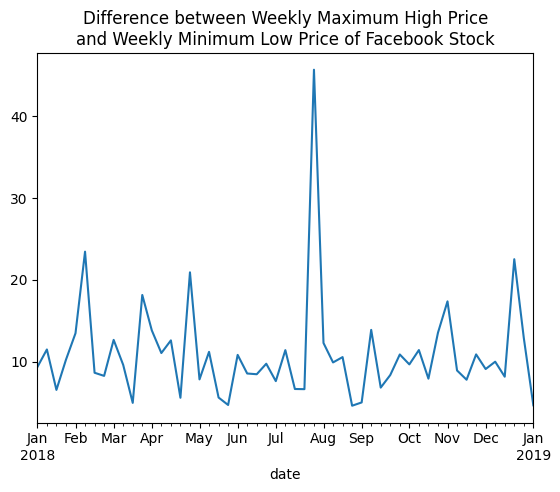

In [131]:
fb.resample('1W').agg(
    dict(high='max', low='min')
).assign(
    max_change_weekly=lambda x: x.high - x.low
).max_change_weekly.plot(
    title='Difference between Weekly Maximum High Price\n'
          'and Weekly Minimum Low Price of Facebook Stock'
)

In [132]:
# Calculate weekly high/low data
weekly_data = fb.resample('1W').agg(dict(high='max', low='min'))
weekly_data['max_change_weekly'] = weekly_data['high'] - weekly_data['low']

# Create Plotly line plot
fig = px.line(
    x=weekly_data.index,
    y=weekly_data['max_change_weekly'],
    title='Difference between Weekly Maximum High Price and Weekly Minimum Low Price of Facebook Stock',
    labels={'x': 'Date', 'y': 'Price Difference ($)'}
)

# Update layout for better appearance
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Price Difference ($)',
    showlegend=False
)

# Add hover template for easier interpretation
fig.update_traces(
    hovertemplate='<b>Weekly Price Range</b><br>' +
                  'Date: %{x}<br>' +
                  'Price Difference: $%{y:.2f}<extra></extra>'
)

fig.show()

## Exercise 1
> Using `seaborn`, create a heatmap to visualize the correlation coefficients between earthquake magnitude and whether there was a tsunami for earthquakes measured with the `mb` magnitude type.

Text(0.5, 1.01, 'Correlation between earthquake magnitude\nand a tsunami')

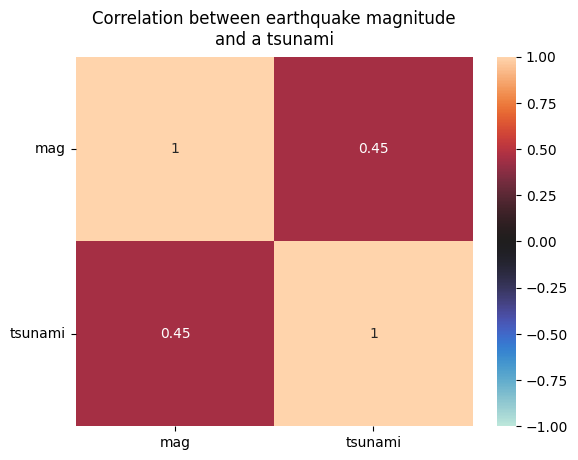

In [142]:
sns.heatmap(
    quakes.loc[quakes['magType'] == 'mb', ['mag','tsunami']].corr(),
    annot=True, center=0, vmin=-1, vmax=1
)
# applying the rotation to make the text more readable
plt.yticks(rotation=0)
plt.title('Correlation between earthquake magnitude\nand a tsunami', y=1.01)

The heatmap shows a positive correlation of 0.45 between earthquake magnitude and a tsunami. This means that as the magnitude of an earthquake increases, the likelihood of a tsunami occurring also increases.

## Exercise 2
> Create a box plot of Facebook volume traded and closing prices and draw reference lines for the bounds of a Tukey fence with a 
> multiplier of 1.5. 
> 
> The bounds will be at Q1 − 1.5 × IQR and Q3 + 1.5 × IQR. 
> 
> Be sure to use the quantile() method on the data to make this easier. 
> 
> Pick whichever orientation you prefer for the plot, but make sure to use subplots.

Text(0.5, 1.1, 'Facebook volume traded and closing price with Tukey Fence bounds')

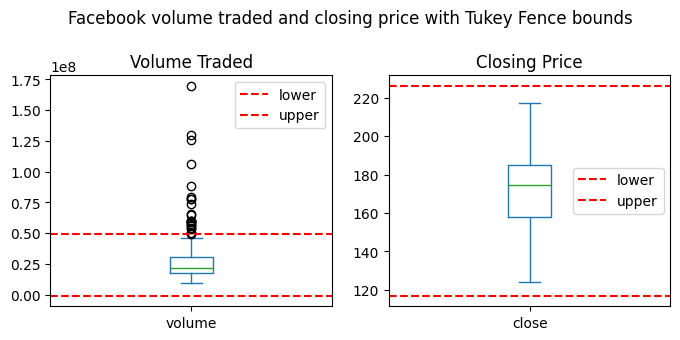

In [ ]:
# Facebook volume traded and closing price with Tukey Fence bounds
cols = ['volume', 'close']
subset = fb[cols]

quantiles = subset.quantile([0.25, 0.75])

# calculate the interquartile range (IQR)
quantiles.loc['iqr',:] = quantiles.loc[0.75,:] - quantiles.loc[0.25,:]

axes = subset.plot(kind='box', subplots=True, figsize=(8, 3), title=['Volume Traded', 'Closing Price'])
# add Tukey fence bounds to each subplot by zipping together axes and cols
for ax, col in zip(axes, cols):
    # get the relevant statistics
    stats = quantiles[col]
    # Calculate the Tukey fence bounds
    lower = stats.loc[0.25] - 1.5 * stats['iqr']
    upper = stats.loc[0.75] + 1.5 * stats['iqr']
    
    # Applying the bounds to the plot
    for bound, name in zip([lower, upper], ['lower', 'upper']):
        ax.axhline(
            bound, 
            color='red', 
            linestyle='dashed',
            label=name
        )
        ax.legend()
plt.suptitle('Facebook volume traded and closing price with Tukey Fence bounds', y=1.1)

The Tukey fence bounds helps us identify potential outliers in the data. It is simply the interquartile range (IQR) multiplied by 1.5 and subtracted from the first quartile (Q1) to get the lower bound, and added to the third quartile (Q3) to get the upper bound.

The volume traded has a very wide range, with some extreme outliers. The closing price has a narrower range, but still has some outliers.